In [2]:
from sklearn.tree import DecisionTreeClassifier
import pandas as pd
import numpy as np 

In [3]:
df=pd.read_csv('heart.csv')
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [4]:
df.target.value_counts()

target
1    526
0    499
Name: count, dtype: int64

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [6]:
# indepedent and dependent
x=df.iloc[:,:-1]
y=df.iloc[:,-1]

In [7]:
y

0       0
1       0
2       0
3       0
4       0
       ..
1020    1
1021    0
1022    0
1023    1
1024    0
Name: target, Length: 1025, dtype: int64

In [8]:
from sklearn.model_selection import train_test_split 

In [9]:
x_train,x_test, y_train, y_test= train_test_split(x,y,test_size=0.30, random_state=41)

In [10]:
x_train

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
686,52,1,0,128,204,1,1,156,1,1.0,1,0,0
397,40,1,0,110,167,0,0,114,1,2.0,1,0,3
312,70,1,2,160,269,0,1,112,1,2.9,1,1,3
345,66,1,1,160,246,0,1,120,1,0.0,1,3,1
821,62,0,0,140,268,0,0,160,0,3.6,0,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
321,48,0,2,130,275,0,1,139,0,0.2,2,0,2
80,50,1,2,140,233,0,1,163,0,0.6,1,1,3
994,59,1,0,110,239,0,0,142,1,1.2,1,1,3
908,62,1,0,120,267,0,1,99,1,1.8,1,2,3


In [11]:
df.shape

(1025, 14)

In [21]:
dt= DecisionTreeClassifier(max_depth=6)

In [22]:
dt.fit(x_train, y_train)
y_pred= dt.predict(x_test)

In [23]:
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score 


In [24]:
confusion_matrix(y_pred, y_test)

array([[123,  12],
       [  4, 169]], dtype=int64)

In [25]:
recall_score(y_test, y_pred)

0.9337016574585635

In [26]:
# post pruning and pre-pruning , and how to make tree....

In [27]:
from sklearn.tree import plot_tree

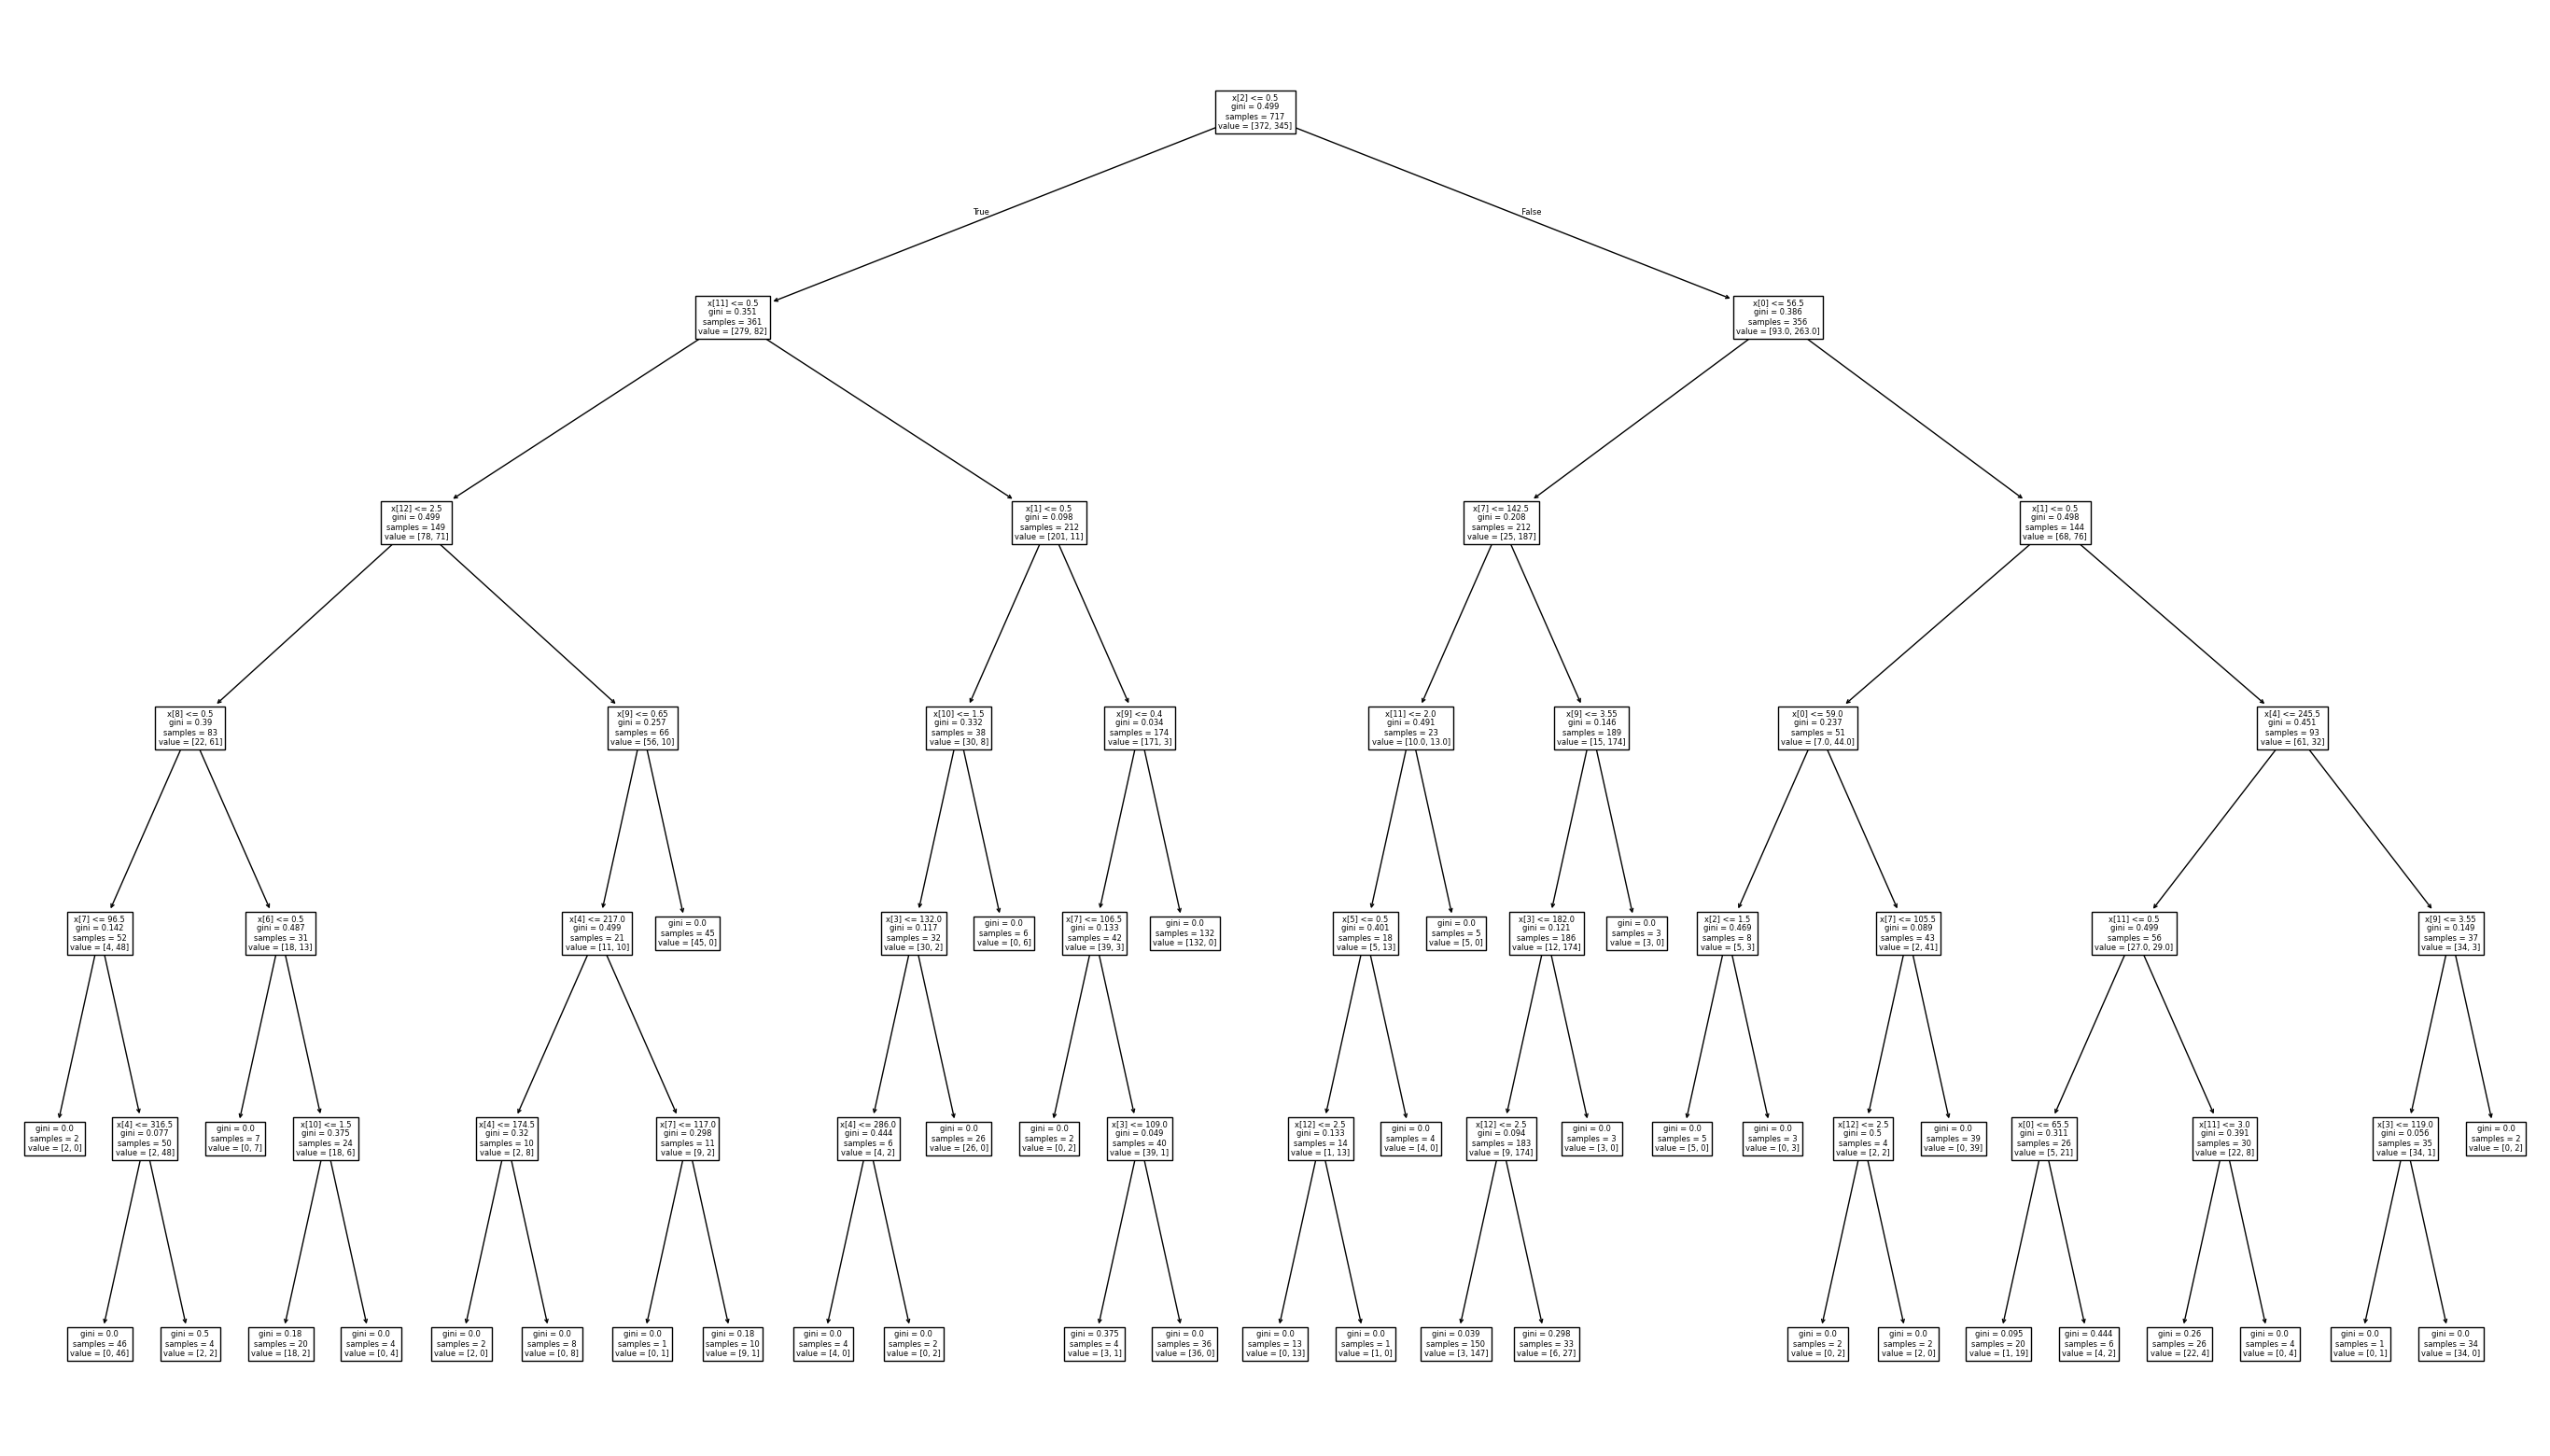

In [28]:
import matplotlib.pyplot as plt 
fig= plt.figure(figsize=(35,20))
plot_tree(dt)
plt.show()

In [29]:
# Pre-pruning - GridSearchCV and RandomSearchCV

In [31]:
from sklearn.model_selection import GridSearchCV

In [32]:
modeldt= DecisionTreeClassifier()

In [33]:
params={
    'criterion':['gini', 'entropy'],
    'max_depth':[5,6,7,8,9,10,11]
}

In [35]:
cv= GridSearchCV(estimator=modeldt,param_grid=params, scoring='accuracy', cv=5)

In [36]:
cv.fit(x_train,y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [5, 6, 7, 8, 9, 10, 11]},
             scoring='accuracy')

In [ ]:
cv.best_params_ 

{'criterion': 'gini', 'max_depth': 11}

In [39]:
model= DecisionTreeClassifier(criterion='gini',max_depth=11)
model.fit(x_train, y_train)
y_pred= model.predict(x_test)

In [40]:
accuracy_score(y_pred, y_test)

0.9902597402597403

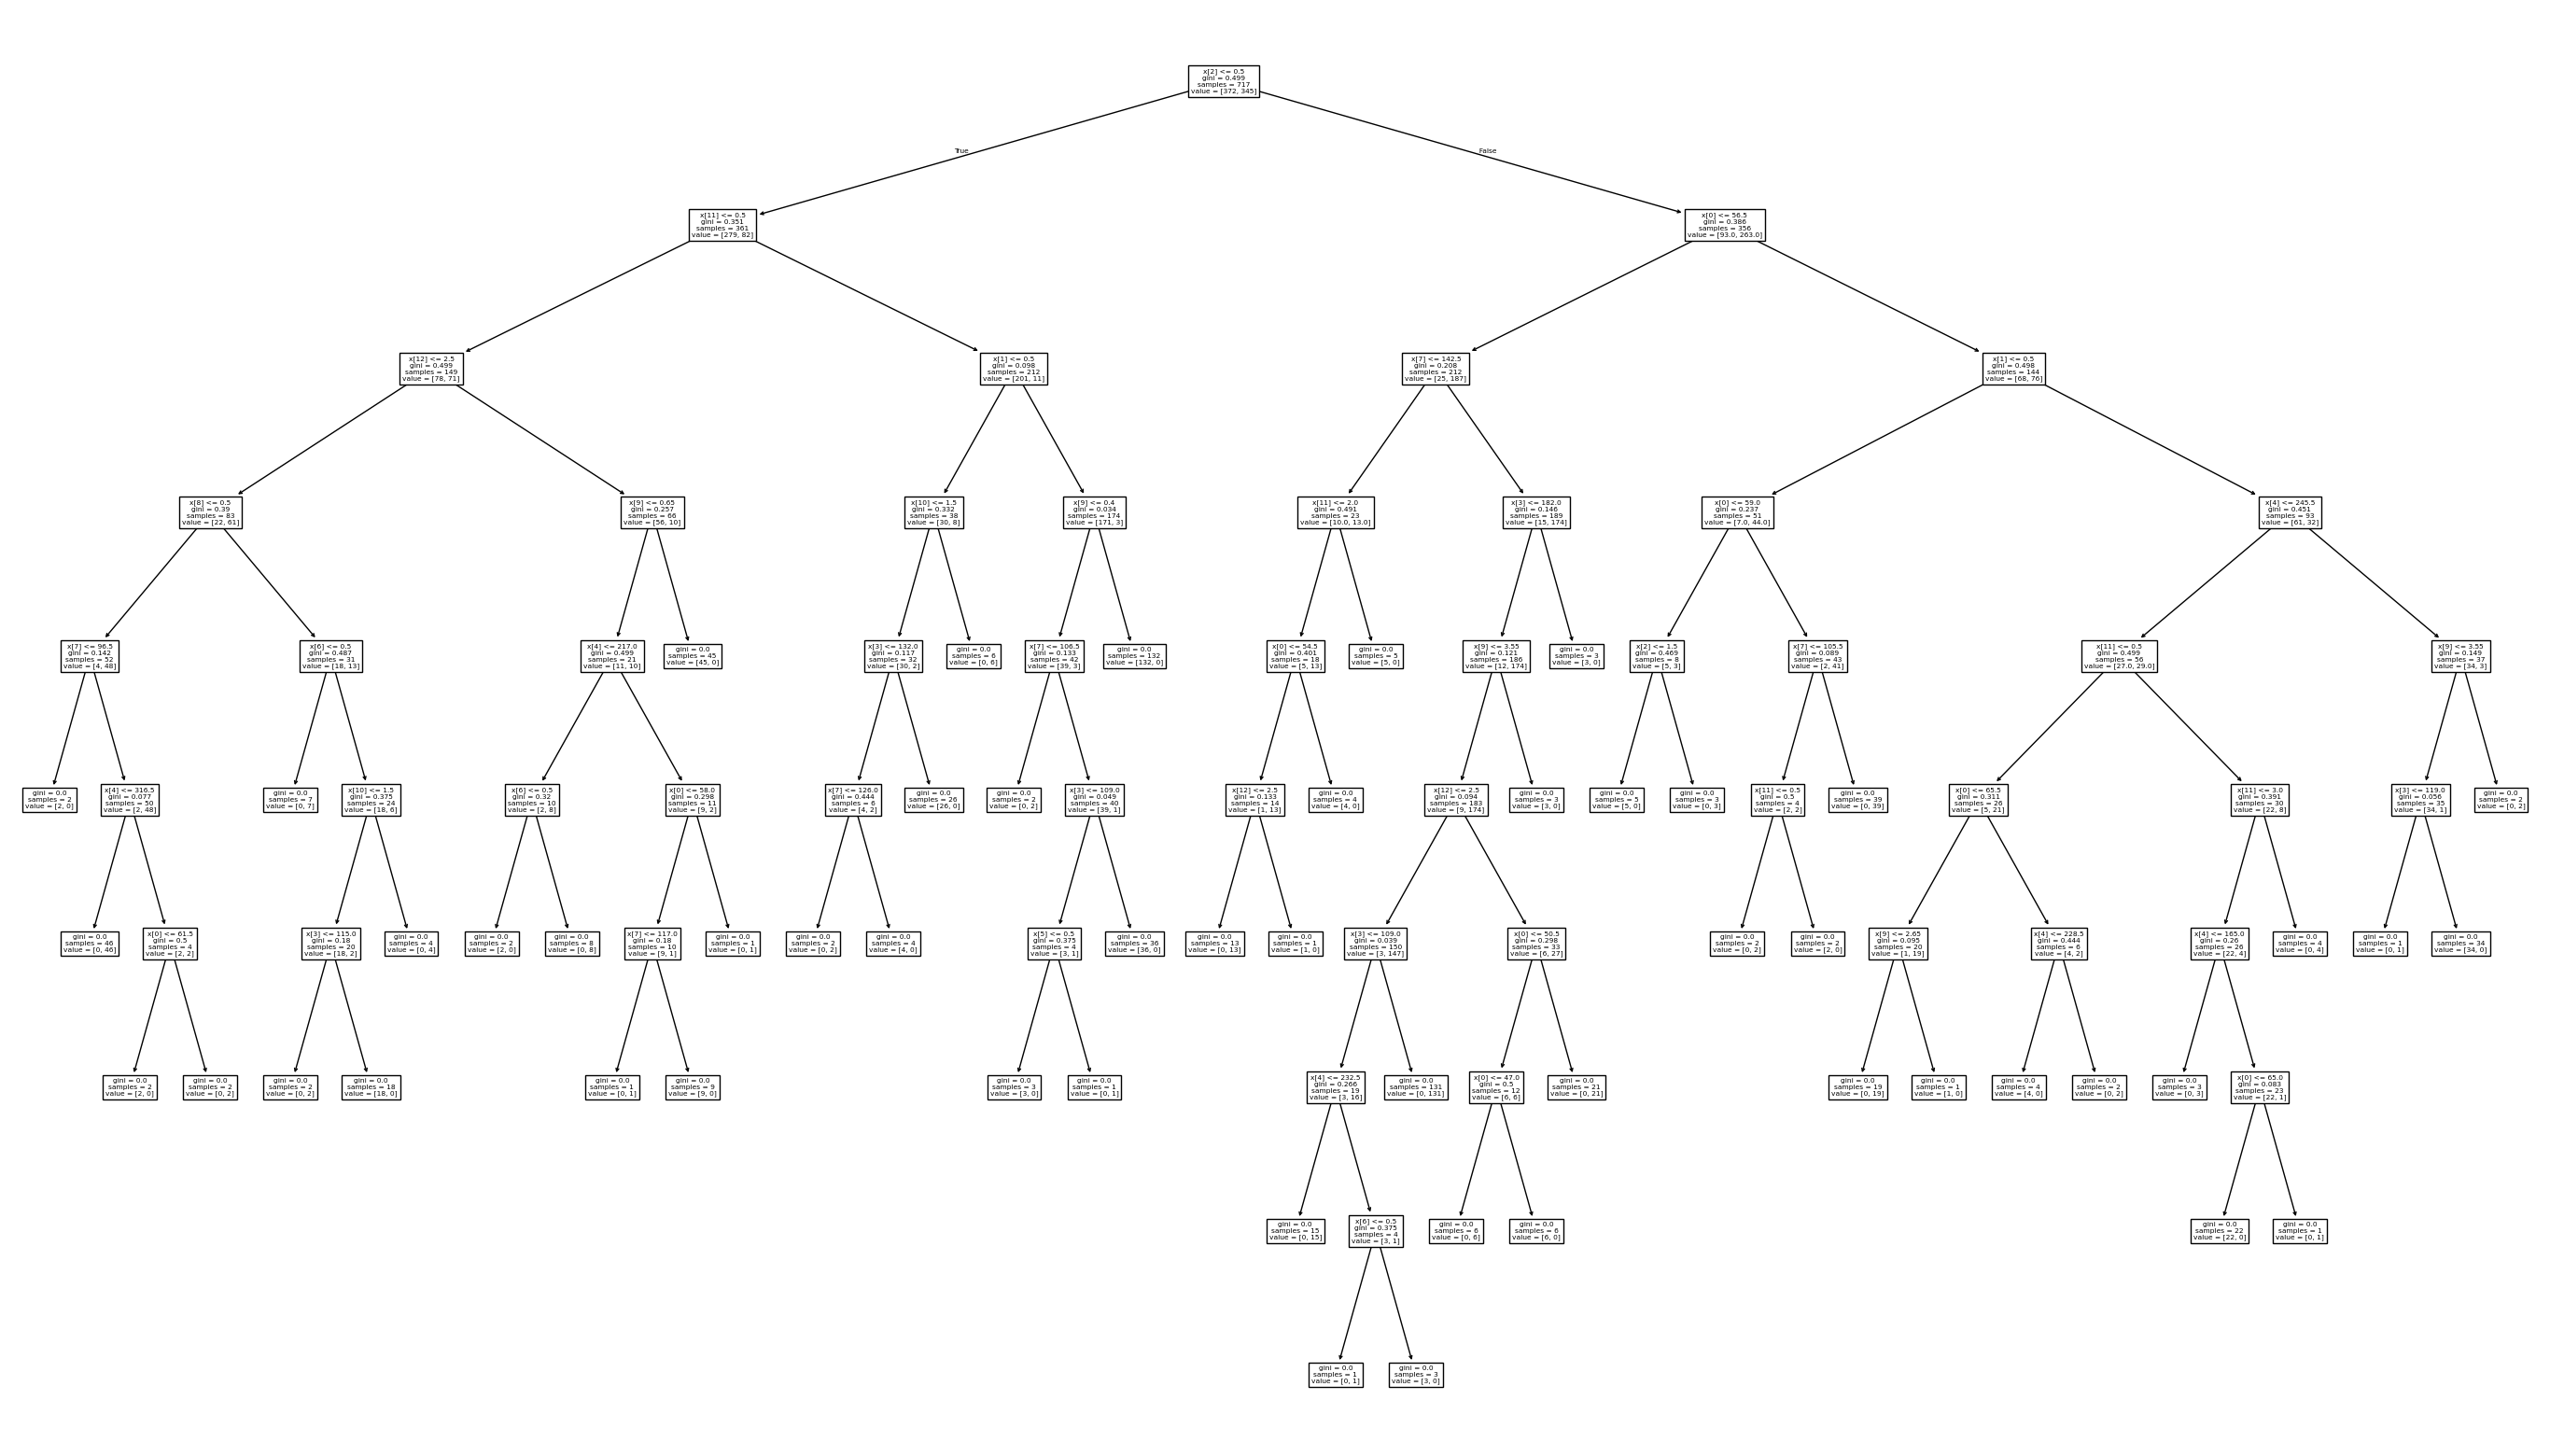

In [42]:
import matplotlib.pyplot as plt 
fig= plt.figure(figsize=(35,20))
plot_tree(model)
plt.show()